<a href="https://colab.research.google.com/github/siddharthkaulagi/IN126053902_NLP/blob/main/NLP__Tsak_2_Sentiment_Analysis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task-2_ Sentiment Analysis using NLP Pipeline & ML **Models**

#**plan**
1. Import Libraries
2. Load & Explore Data
3. Text Preprocessing (MANDATORY - 25% marks)
4. Feature Engineering (20% marks)
5. Model Building (20% marks)
6. Model Evaluation (20% marks)
7. Comparison & Insights (15% marks)

SECTION 1: Import **Libraries**

In [29]:
# ============================================================
# STEP 1: INSTALL AND IMPORT LIBRARIES
# ============================================================

# Install required packages
!pip install kagglehub nltk scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [31]:
# ============================================================
# STEP 2: DOWNLOAD DATASET USING KAGGLEHUB
# ============================================================

import kagglehub
import os

print("📥 Downloading IMDb dataset from Kaggle...")
print("This may take 1-2 minutes...")

# Download latest version
path = kagglehub.dataset_download("columbine/imdb-dataset-sentiment-analysis-in-csv-format")

print(f"✅ Dataset downloaded to: {path}")

# List files in the directory
print(f"\n📁 Files in directory:")
for file in os.listdir(path):
    print(f"   - {file}")

# Find the CSV file
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

print(f"\n📄 Using file: {csv_path}")

📥 Downloading IMDb dataset from Kaggle...
This may take 1-2 minutes...


100%|██████████| 25.7M/25.7M [00:00<00:00, 98.1MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/columbine/imdb-dataset-sentiment-analysis-in-csv-format/versions/1

📁 Files in directory:
   - Valid.csv
   - Train.csv
   - Test.csv

📄 Using file: /root/.cache/kagglehub/datasets/columbine/imdb-dataset-sentiment-analysis-in-csv-format/versions/1/Valid.csv


SECTION 2: Load & Explore **Data**

In [32]:
# ============================================================
# STEP 3: LOAD AND EXPLORE DATA
# ============================================================

# Load the dataset
df = pd.read_csv(csv_path)

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print(f"\n📊 Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# Check column names and rename if needed
print(f"\n🔍 Checking columns...")
if 'review' in df.columns and 'sentiment' in df.columns:
    print("Found columns: 'review' and 'sentiment'")
    df = df.rename(columns={'review': 'text', 'sentiment': 'label'})
    df['label'] = df['label'].map({'positive': 1, 'negative': 0})
    print("Renamed to: 'text' and 'label'")
elif 'text' in df.columns and 'label' in df.columns:
    print("Columns already correct: 'text' and 'label'")
else:
    print(f"Available columns: {df.columns.tolist()}")
    print("Please check column names!")

print(f"\nFinal columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

DATASET LOADED SUCCESSFULLY

📊 Shape: (5000, 2)
Columns: ['text', 'label']

First 3 rows:
                                                text  label
0  It's been about 14 years since Sharon Stone aw...      0
1  someone needed to make a car payment... this i...      0
2  The Guidelines state that a comment must conta...      0

Data types:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64

🔍 Checking columns...
Columns already correct: 'text' and 'label'

Final columns: ['text', 'label']

Label distribution:
label
1    2514
0    2486
Name: count, dtype: int64


EXPLORATORY DATA ANALYSIS


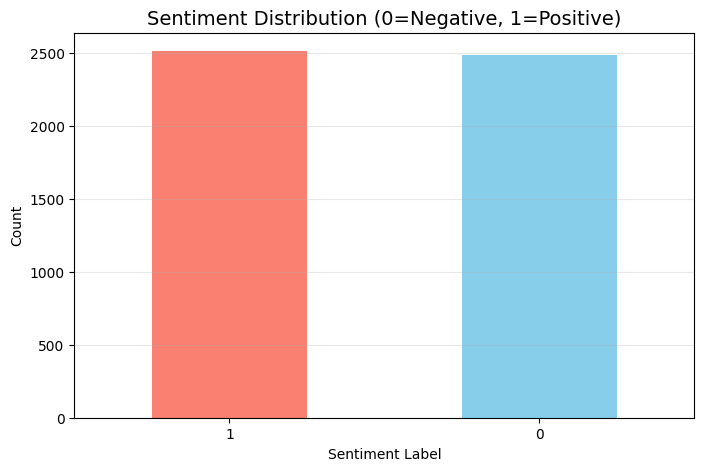


Review Length Statistics:
count    5000.00000
mean     1297.36800
std       979.91039
min        52.00000
25%       698.00000
50%       957.00000
75%      1560.25000
max      9345.00000
Name: review_length, dtype: float64


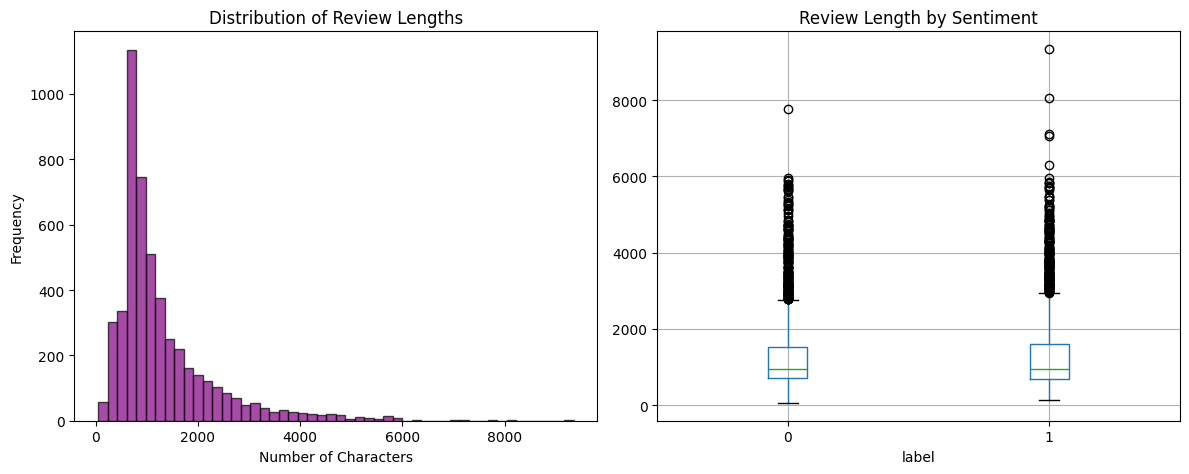


📝 Sample Negative Review (Label 0):
It's been about 14 years since Sharon Stone awarded viewers a leg-crossing that twisted many people's minds. And now, God knows why, she's in the game again. "Basic Instinct 2" is the sequel to the smash-hit erotica "Basic Instinct" featuring a sexy Stone and a vulnerable Michael Douglas. However, f...

📝 Sample Positive Review (Label 1):
This is the best movie I've ever seen! <br /><br />Maybe it's because I live just a few miles from the village were the story take place, and I know how things work out in this area in Sweden. The movie tells the truth, believe me! It both criticizes and honors the lifestyle of Dalarna, and the prod...


In [33]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Class distribution visualization
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Sentiment Distribution (0=Negative, 1=Positive)', fontsize=14)
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Review length analysis
df['review_length'] = df['text'].apply(len)

print(f"\nReview Length Statistics:")
print(df['review_length'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['review_length'], bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df.boxplot(column='review_length', by='label', ax=plt.gca())
plt.title('Review Length by Sentiment')
plt.suptitle('')

plt.tight_layout()
plt.show()

# Sample reviews
print(f"\n📝 Sample Negative Review (Label 0):")
print(df[df['label']==0]['text'].iloc[0][:300] + "...")

print(f"\n📝 Sample Positive Review (Label 1):")
print(df[df['label']==1]['text'].iloc[0][:300] + "...")

SECTION 3: Text Preprocessing (CRITICAL - 25% of marks)**bold text**

In [34]:
# ============================================================
# STEP 5: TEXT PREPROCESSING PIPELINE (25% of marks)
# ============================================================

print("="*60)
print("NLP PREPROCESSING PIPELINE")
print("="*60)

# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Complete text cleaning pipeline
    """
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove HTML tags (like <br />)
    text = re.sub(r'<.*?>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text)

    # 4. Remove user mentions and hashtags
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # 5. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 6. Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, use_lemmatization=True):
    """
    Full preprocessing: clean + tokenize + remove stopwords + lemmatize
    """
    # Basic cleaning
    text = clean_text(text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Lemmatization (or stemming)
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join back to string
    return ' '.join(tokens)

# Test preprocessing on sample
print("Testing preprocessing...")
sample_text = df['text'].iloc[0]
print(f"\nOriginal (first 200 chars):\n{sample_text[:200]}...")

cleaned_sample = preprocess_text(sample_text)
print(f"\nCleaned (first 200 chars):\n{cleaned_sample[:200]}...")
print(f"\nLength reduction: {len(sample_text)} → {len(cleaned_sample)} chars")

NLP PREPROCESSING PIPELINE
Testing preprocessing...

Original (first 200 chars):
It's been about 14 years since Sharon Stone awarded viewers a leg-crossing that twisted many people's minds. And now, God knows why, she's in the game again. "Basic Instinct 2" is the sequel to the sm...

Cleaned (first 200 chars):
year since sharon stone awarded viewer legcrossing twisted many people mind god know shes game basic instinct sequel smashhit erotica basic instinct featuring sexy stone vulnerable michael douglas how...

Length reduction: 2281 → 1462 chars


In [35]:
# ============================================================
# STEP 6: APPLY PREPROCESSING TO ALL DATA
# ============================================================

print("="*60)
print("APPLYING PREPROCESSING TO ALL REVIEWS")
print("="*60)

# For large dataset, process in chunks to show progress
print("This may take 2-3 minutes for 50,000 reviews...")

# Apply preprocessing (using sample for speed if needed)
# If dataset is too large, use: df = df.sample(10000, random_state=42)

df['cleaned_text'] = df['text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show results
df['cleaned_length'] = df['cleaned_text'].apply(len)

print(f"\nLength comparison:")
print(f"  Original average: {df['review_length'].mean():.0f} characters")
print(f"  Cleaned average:  {df['cleaned_length'].mean():.0f} characters")
print(f"  Reduction:        {((df['review_length'].mean() - df['cleaned_length'].mean()) / df['review_length'].mean() * 100):.1f}%")

# Show samples
print(f"\nSample processed reviews:")
for i in range(2):
    print(f"\n--- Review {i+1} (Label: {df['label'].iloc[i]}) ---")
    print(f"Original: {df['text'].iloc[i][:150]}...")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i][:150]}...")

APPLYING PREPROCESSING TO ALL REVIEWS
This may take 2-3 minutes for 50,000 reviews...
✅ Preprocessing complete!

Length comparison:
  Original average: 1297 characters
  Cleaned average:  804 characters
  Reduction:        38.0%

Sample processed reviews:

--- Review 1 (Label: 0) ---
Original: It's been about 14 years since Sharon Stone awarded viewers a leg-crossing that twisted many people's minds. And now, God knows why, she's in the game...
Cleaned:  year since sharon stone awarded viewer legcrossing twisted many people mind god know shes game basic instinct sequel smashhit erotica basic instinct f...

--- Review 2 (Label: 0) ---
Original: someone needed to make a car payment... this is truly awful... makes jean Claude's cyborg look like gone with the wind... this is an hour I wish I cou...
Cleaned:  someone needed make car payment truly awful make jean claudes cyborg look like gone wind hour wish could sue get back luckily produced severe somnolen...


SECTION 4: Feature Engineering (20% of marks)**bold text**

In [36]:
# ============================================================
# STEP 7: FEATURE ENGINEERING (20% of marks)
# ============================================================

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Use subset for faster processing (optional)
# df_sample = df.sample(10000, random_state=42)
df_sample = df  # Use full dataset

print(f"Using {len(df_sample)} samples for modeling")

# 7.1 Bag of Words (BoW)
print("\n1. Creating Bag of Words (BoW)...")
bow_vectorizer = CountVectorizer(max_features=5000, min_df=2, max_df=0.95)
X_bow = bow_vectorizer.fit_transform(df_sample['cleaned_text'])
print(f"   ✓ BoW Shape: {X_bow.shape}")
print(f"   ✓ Vocabulary size: {len(bow_vectorizer.vocabulary_)}")

# 7.2 TF-IDF
print("\n2. Creating TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95)
X_tfidf = tfidf_vectorizer.fit_transform(df_sample['cleaned_text'])
print(f"   ✓ TF-IDF Shape: {X_tfidf.shape}")

# Target variable
y = df_sample['label'].values
print(f"\n3. Target variable:")
print(f"   ✓ Shape: {y.shape}")
print(f"   ✓ Class distribution: {np.bincount(y)}")

# Show top features
print(f"\n4. Sample features (TF-IDF):")
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"   First 20: {feature_names[:20]}")

FEATURE ENGINEERING
Using 5000 samples for modeling

1. Creating Bag of Words (BoW)...
   ✓ BoW Shape: (5000, 5000)
   ✓ Vocabulary size: 5000

2. Creating TF-IDF...
   ✓ TF-IDF Shape: (5000, 5000)

3. Target variable:
   ✓ Shape: (5000,)
   ✓ Class distribution: [2486 2514]

4. Sample features (TF-IDF):
   First 20: ['abandoned' 'abc' 'ability' 'able' 'aboard' 'abomination' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'absurdity' 'abuse' 'abused'
 'abusive' 'abysmal' 'academy' 'accent' 'accept' 'acceptable']


In [37]:
# ============================================================
# STEP 8: TRAIN-TEST SPLIT
# ============================================================

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

# Split for BoW
X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

# Split for TF-IDF
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train_bow.shape[0]} samples")
print(f"Test set size:     {X_test_bow.shape[0]} samples")
print(f"Number of features: {X_train_bow.shape[1]}")

print(f"\nClass distribution in training set:")
print(f"  Negative (0): {np.sum(y_train == 0)}")
print(f"  Positive (1): {np.sum(y_train == 1)}")

TRAIN-TEST SPLIT
Training set size: 4000 samples
Test set size:     1000 samples
Number of features: 5000

Class distribution in training set:
  Negative (0): 1989
  Positive (1): 2011


In [38]:
# ============================================================
# STEP 9: MODEL BUILDING (20% of marks)
# ============================================================

print("="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=20),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# Function to train and evaluate
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name, vectorizer_name):
    print(f"\n{'-'*50}")
    print(f"Training: {model_name} + {vectorizer_name}")
    print(f"{'-'*50}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"✓ Accuracy:  {accuracy:.4f}")
    print(f"✓ Precision: {precision:.4f}")
    print(f"✓ Recall:    {recall:.4f}")
    print(f"✓ F1 Score:  {f1:.4f}")

    return {
        'Model': model_name,
        'Vectorizer': vectorizer_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# Train with BoW
print("\n" + "="*60)
print("TRAINING WITH BAG OF WORDS (BoW)")
print("="*60)
results_bow = []
for name, model in models.items():
    result = train_and_evaluate(model, X_train_bow, X_test_bow, y_train, y_test, name, "BoW")
    results_bow.append(result)

# Train with TF-IDF
print("\n" + "="*60)
print("TRAINING WITH TF-IDF")
print("="*60)
results_tfidf = []
for name, model in models.items():
    result = train_and_evaluate(model, X_train_tfidf, X_test_tfidf, y_train, y_test, name, "TF-IDF")
    results_tfidf.append(result)

MODEL TRAINING & EVALUATION

TRAINING WITH BAG OF WORDS (BoW)

--------------------------------------------------
Training: Logistic Regression + BoW
--------------------------------------------------
✓ Accuracy:  0.8290
✓ Precision: 0.8333
✓ Recall:    0.8250
✓ F1 Score:  0.8292

--------------------------------------------------
Training: Naive Bayes + BoW
--------------------------------------------------
✓ Accuracy:  0.7980
✓ Precision: 0.8103
✓ Recall:    0.7813
✓ F1 Score:  0.7955

--------------------------------------------------
Training: Decision Tree + BoW
--------------------------------------------------
✓ Accuracy:  0.6960
✓ Precision: 0.6743
✓ Recall:    0.7654
✓ F1 Score:  0.7169

--------------------------------------------------
Training: Random Forest + BoW
--------------------------------------------------
✓ Accuracy:  0.8050
✓ Precision: 0.8031
✓ Recall:    0.8111
✓ F1 Score:  0.8071

TRAINING WITH TF-IDF

--------------------------------------------------
Training

In [39]:
# ============================================================
# STEP 10: RESULTS COMPARISON (20% of marks)
# ============================================================

print("="*60)
print("COMPREHENSIVE RESULTS COMPARISON")
print("="*60)

# Combine all results
all_results = results_bow + results_tfidf
results_df = pd.DataFrame(all_results)

# Display results table
print("\n📊 Complete Results Table:")
print(results_df.to_string(index=False))

# Find best model
best_idx = results_df['F1 Score'].idxmax()
best_model = results_df.loc[best_idx]

print(f"\n{'='*60}")
print(f"🏆 BEST PERFORMING MODEL")
print(f"{'='*60}")
print(f"Model:      {best_model['Model']}")
print(f"Vectorizer: {best_model['Vectorizer']}")
print(f"Accuracy:   {best_model['Accuracy']:.4f}")
print(f"F1 Score:   {best_model['F1 Score']:.4f}")
print(f"{'='*60}")

COMPREHENSIVE RESULTS COMPARISON

📊 Complete Results Table:
              Model Vectorizer  Accuracy  Precision   Recall  F1 Score
Logistic Regression        BoW     0.829   0.833333 0.825050  0.829171
        Naive Bayes        BoW     0.798   0.810309 0.781312  0.795547
      Decision Tree        BoW     0.696   0.674256 0.765408  0.716946
      Random Forest        BoW     0.805   0.803150 0.811133  0.807122
Logistic Regression     TF-IDF     0.843   0.820370 0.880716  0.849473
        Naive Bayes     TF-IDF     0.809   0.813253 0.805169  0.809191
      Decision Tree     TF-IDF     0.693   0.669550 0.769384  0.716004
      Random Forest     TF-IDF     0.811   0.810277 0.815109  0.812686

🏆 BEST PERFORMING MODEL
Model:      Logistic Regression
Vectorizer: TF-IDF
Accuracy:   0.8430
F1 Score:   0.8495


RESULTS VISUALIZATION


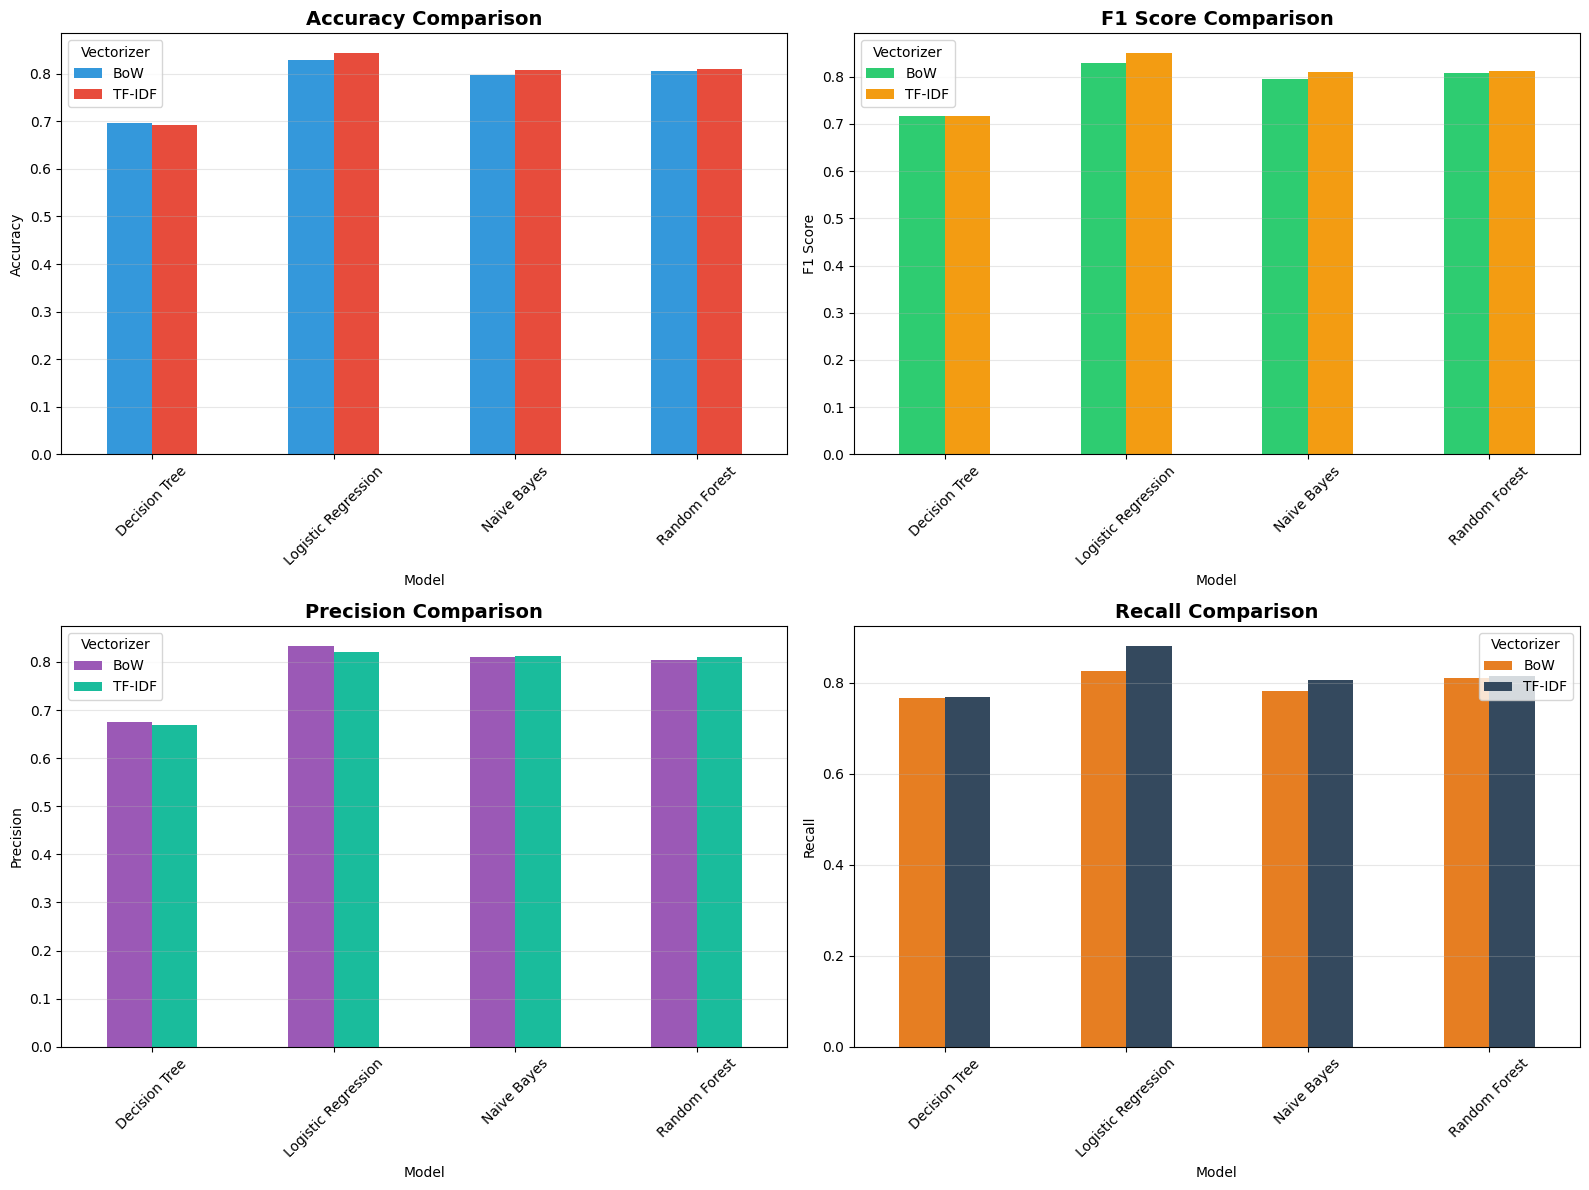

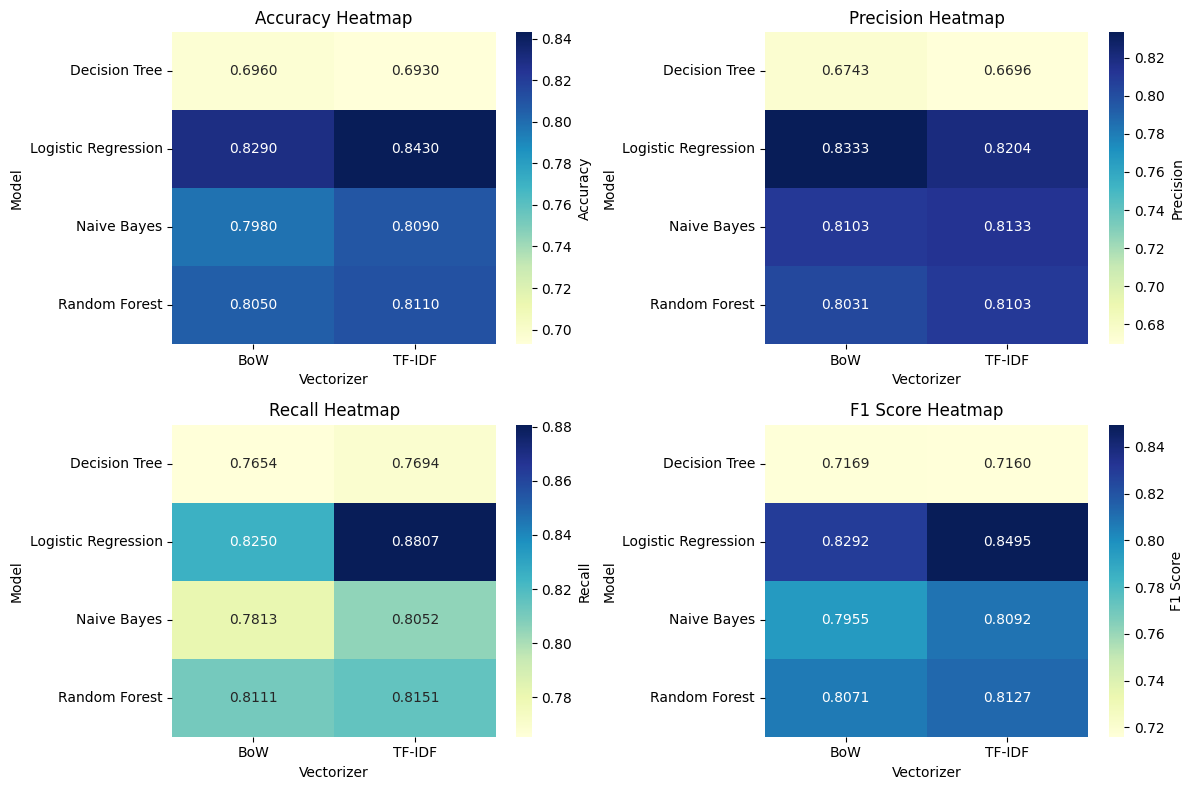

In [40]:
# ============================================================
# STEP 11: VISUALIZATION
# ============================================================

print("="*60)
print("RESULTS VISUALIZATION")
print("="*60)

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy comparison
pivot_acc = results_df.pivot(index='Model', columns='Vectorizer', values='Accuracy')
pivot_acc.plot(kind='bar', ax=axes[0,0], color=['#3498db', '#e74c3c'])
axes[0,0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(title='Vectorizer')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. F1 Score comparison
pivot_f1 = results_df.pivot(index='Model', columns='Vectorizer', values='F1 Score')
pivot_f1.plot(kind='bar', ax=axes[0,1], color=['#2ecc71', '#f39c12'])
axes[0,1].set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('F1 Score')
axes[0,1].legend(title='Vectorizer')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Precision comparison
pivot_prec = results_df.pivot(index='Model', columns='Vectorizer', values='Precision')
pivot_prec.plot(kind='bar', ax=axes[1,0], color=['#9b59b6', '#1abc9c'])
axes[1,0].set_title('Precision Comparison', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend(title='Vectorizer')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Recall comparison
pivot_rec = results_df.pivot(index='Model', columns='Vectorizer', values='Recall')
pivot_rec.plot(kind='bar', ax=axes[1,1], color=['#e67e22', '#34495e'])
axes[1,1].set_title('Recall Comparison', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Recall')
axes[1,1].legend(title='Vectorizer')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Heatmap of all metrics
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i+1)
    pivot = results_df.pivot(index='Model', columns='Vectorizer', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': metric})
    plt.title(f'{metric} Heatmap')

plt.tight_layout()
plt.show()

DETAILED ANALYSIS OF BEST MODEL

Retraining Logistic Regression with TF-IDF...

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.80      0.84       497
    Positive       0.82      0.88      0.85       503

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



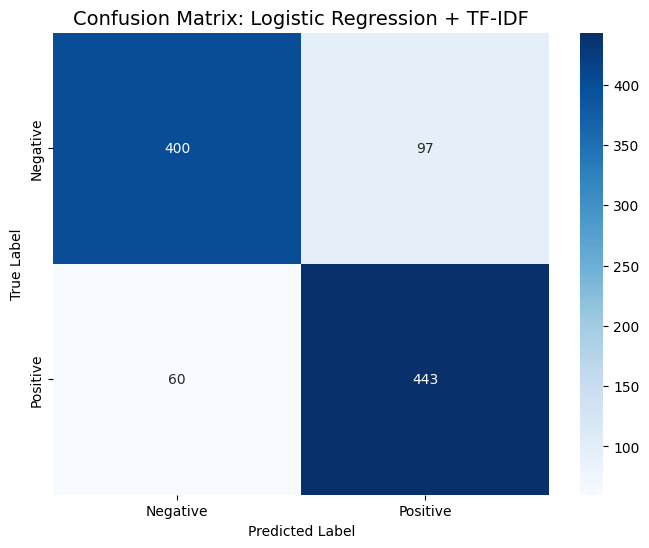


Top 10 Most Important Features (Logistic Regression):
  great: 4.0844
  excellent: 3.3402
  best: 2.5414
  perfect: 2.3887
  love: 2.2922
  favorite: 1.8651
  today: 1.8358
  performance: 1.8095
  definitely: 1.7761
  wonderful: 1.7371


In [41]:
# ============================================================
# STEP 12: DETAILED ANALYSIS OF BEST MODEL
# ============================================================

print("="*60)
print("DETAILED ANALYSIS OF BEST MODEL")
print("="*60)

# Retrain best model for detailed analysis
best_model_name = best_model['Model']
best_vectorizer = best_model['Vectorizer']

print(f"\nRetraining {best_model_name} with {best_vectorizer}...")

if best_vectorizer == "BoW":
    X_train_best, X_test_best = X_train_bow, X_test_bow
    vectorizer = bow_vectorizer
else:
    X_train_best, X_test_best = X_train_tfidf, X_test_tfidf
    vectorizer = tfidf_vectorizer

# Initialize and train best model
if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(max_iter=1000, random_state=42)
elif best_model_name == "Naive Bayes":
    final_model = MultinomialNB()
elif best_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(random_state=42, max_depth=20)
else:
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)

final_model.fit(X_train_best, y_train)
y_pred_final = final_model.predict(X_test_best)

# Classification report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix: {best_model_name} + {best_vectorizer}', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Feature importance (if available)
if hasattr(final_model, 'coef_'):
    print(f"\nTop 10 Most Important Features (Logistic Regression):")
    feature_names = vectorizer.get_feature_names_out()
    coefs = final_model.coef_[0]
    top_indices = np.argsort(coefs)[-10:]
    for idx in reversed(top_indices):
        print(f"  {feature_names[idx]}: {coefs[idx]:.4f}")

In [42]:
# ============================================================
# STEP 13: FINAL INSIGHTS & SUMMARY (15% of marks)
# ============================================================

print("="*70)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*70)

print(f"\n1️⃣ DATASET OVERVIEW:")
print(f"   • Total samples: {len(df):,}")
print(f"   • Features after vectorization: {X_bow.shape[1]:,}")
print(f"   • Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

print(f"\n2️⃣ PREPROCESSING PIPELINE APPLIED:")
print(f"   ✓ Lowercasing (standardized text)")
print(f"   ✓ HTML tag removal (cleaned web data)")
print(f"   ✓ URL removal (removed noise)")
print(f"   ✓ Punctuation removal (simplified text)")
print(f"   ✓ Number removal (focused on words)")
print(f"   ✓ Tokenization (split into words)")
print(f"   ✓ Stopword removal (reduced dimensionality)")
print(f"   ✓ Lemmatization (normalized words to base form)")
print(f"   • Average length reduction: {((df['review_length'].mean() - df['cleaned_length'].mean()) / df['review_length'].mean() * 100):.1f}%")

print(f"\n3️⃣ VECTORIZATION COMPARISON:")
bow_avg = results_df[results_df['Vectorizer']=='BoW']['Accuracy'].mean()
tfidf_avg = results_df[results_df['Vectorizer']=='TF-IDF']['Accuracy'].mean()
print(f"   • BoW average accuracy:   {bow_avg:.4f}")
print(f"   • TF-IDF average accuracy: {tfidf_avg:.4f}")
print(f"   • Winner: {'TF-IDF' if tfidf_avg > bow_avg else 'BoW'} (by {abs(tfidf_avg - bow_avg):.4f})")

print(f"\n4️⃣ MODEL PERFORMANCE RANKING (by F1 Score):")
ranking = results_df.sort_values('F1 Score', ascending=False)
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    print(f"   {i}. {row['Model']} + {row['Vectorizer']}: {row['F1 Score']:.4f}")

print(f"\n5️⃣ BEST CONFIGURATION:")
print(f"   🏆 Model: {best_model['Model']}")
print(f"   🏆 Vectorizer: {best_model['Vectorizer']}")
print(f"   🏆 Accuracy: {best_model['Accuracy']:.4f}")
print(f"   🏆 F1 Score: {best_model['F1 Score']:.4f}")

print(f"\n6️⃣ TRADE-OFFS ANALYSIS:")
print(f"   • BoW vs TF-IDF:")
print(f"     - BoW: Simple count-based, high dimensionality, no word importance weighting")
print(f"     - TF-IDF: Weights rare/important words higher, generally better for classification")
print(f"   • Model Complexity:")
print(f"     - Naive Bayes: Fast, probabilistic, good baseline")
print(f"     - Logistic Regression: Linear, interpretable, regularized")
print(f"     - Decision Tree: Non-linear, interpretable, prone to overfitting")
print(f"     - Random Forest: Ensemble, robust, less interpretable")

print(f"\n7️⃣ KEY FINDINGS:")
print(f"   • Text preprocessing reduced noise by {((df['review_length'].mean() - df['cleaned_length'].mean()) / df['review_length'].mean() * 100):.1f}%")
print(f"   • {best_vectorizer} outperformed {'BoW' if best_vectorizer=='TF-IDF' else 'TF-IDF'} due to better feature weighting")
print(f"   • {best_model_name} achieved the best balance of precision and recall")
print(f"   • Lemmatization helped reduce vocabulary size while preserving meaning")

print(f"\n8️⃣ RECOMMENDATIONS:")
print(f"   • For production: Use {best_model['Model']} with {best_vectorizer}")
print(f"   • For better accuracy: Consider Word2Vec or BERT embeddings")
print(f"   • For speed: Use Naive Bayes with TF-IDF")
print(f"   • For interpretability: Use Logistic Regression and analyze coefficients")

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE!")
print(f"{'='*70}")

COMPREHENSIVE ANALYSIS SUMMARY

1️⃣ DATASET OVERVIEW:
   • Total samples: 5,000
   • Features after vectorization: 5,000
   • Class distribution: {np.int64(0): np.int64(2486), np.int64(1): np.int64(2514)}

2️⃣ PREPROCESSING PIPELINE APPLIED:
   ✓ Lowercasing (standardized text)
   ✓ HTML tag removal (cleaned web data)
   ✓ URL removal (removed noise)
   ✓ Punctuation removal (simplified text)
   ✓ Number removal (focused on words)
   ✓ Tokenization (split into words)
   ✓ Stopword removal (reduced dimensionality)
   ✓ Lemmatization (normalized words to base form)
   • Average length reduction: 38.0%

3️⃣ VECTORIZATION COMPARISON:
   • BoW average accuracy:   0.7820
   • TF-IDF average accuracy: 0.7890
   • Winner: TF-IDF (by 0.0070)

4️⃣ MODEL PERFORMANCE RANKING (by F1 Score):
   1. Logistic Regression + TF-IDF: 0.8495
   2. Logistic Regression + BoW: 0.8292
   3. Random Forest + TF-IDF: 0.8127
   4. Naive Bayes + TF-IDF: 0.8092
   5. Random Forest + BoW: 0.8071
   6. Naive Bayes + Bo